Study the convergence for different values of curvature

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import xtrack as xt
import bpmeth
import sympy as sp

b1 commands curvature here

curvature h[m^-1]:  0.3 radius of curvature [m]:  3.3333333333333335
E [GeV]:  1.03827208816
beta0:  0.42819548497881543
xinit= [-0.00166667 -0.00083333  0.          0.00083333  0.00166667]
nphi= 5


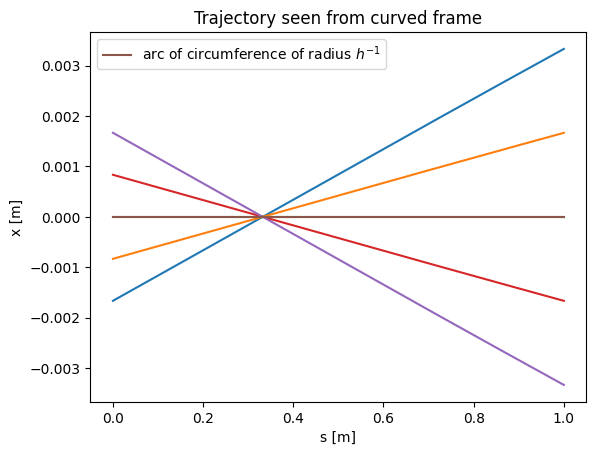

In [21]:
a_curved = [0,]
b_curved = [0.3, 0.02]
h= b_curved[0]# considering normalization B/Brho=1/rho=h            =1. if checking for a drift
print("curvature h[m^-1]: ", h, "radius of curvature [m]: ", 1/h)
#I want to track protons of given kinetic energy
Ek=1e8 #eV
p=np.sqrt(Ek**2+2*Ek*xt.PROTON_MASS_EV)#momentum eV/c
Eref = Ek + xt.PROTON_MASS_EV
print("E [GeV]: ", Eref/1e9)
gamma0 = Eref/xt.PROTON_MASS_EV
beta0 = np.sqrt(1-1/gamma0**2)
print("beta0: ", beta0)
hx_max=5e-4#maximum product of h and x between for initial conditions, to avoid the singularity in the vector potential
xinit=np.linspace(-1, 1, 5)*hx_max/h
print("xinit=",xinit)
p0 =xt.Particles(x=xinit, y=0, s=0, py=np.linspace(0.005,-0.005,5), px=np.linspace(0.005,-0.005,5), ptau=0, beta0=beta0, energy0=Eref, mass0=xt.PROTON_MASS_EV)
p_1 = p0.copy()
nphi=5 #default is 5
print("nphi=",nphi)
A_curved= bpmeth.GeneralVectorPotential(h=h, b=b_curved, a=a_curved, nphi=nphi)
bending_angle=0.3#rad, fix for all the tests
fixedlength=bending_angle/h
H_curved = bpmeth.Hamiltonian(length=fixedlength, h=h, vectp=A_curved)

sol_curved = H_curved.track(p_1, return_sol=True, ivp_opt= {"rtol":1e-10, "atol":1e-12})

for ss in sol_curved:
    plt.plot(ss.t, ss.y[0])
plt.xlabel('s [m]')
plt.ylabel('x [m]')
plt.title("Trajectory seen from curved frame")
x=np.linspace(0,1,50)
y= np.zeros_like(x)
plt.plot(x,y, label='arc of circumference of radius $h^{-1}$')
plt.legend()
plt.show()

In [22]:
expansion_curved = bpmeth.FieldExpansion(a=a_curved, b=b_curved, h=h, nphi=5)#, nphi=nphi)
phi_curved = expansion_curved.get_phi()
print("phi curved frame: ", phi_curved)
#transform the scalar potential to curved frame using coordinate transformations
#xcurved =sqrt((x+rho)**2+s**2)-rho       scurved=rho*arctan(s/(x+rho))   with rho=1/h
x, y, s = sp.symbols('x y s', real=True)
xtmp, stmp = sp.symbols("xtmp stmp", real=True)
# rename the curved coordinates temporarily
phi_tmp = phi_curved.xreplace({
    x: xtmp,
    s: stmp
})
# substitute curved -> straight
phi_straight = phi_tmp.xreplace({
    xtmp: sp.sqrt((x + 1/h)**2 + s**2) - 1/h,
    stmp: 1/h * sp.atan(s/(x + 1/h))
})
print("\nphi straight frame: ", phi_straight)

Bxstraight_ana = -phi_straight.diff(x)
Bystraight_ana = -phi_straight.diff(y)
Bsstraight_ana = -phi_straight.diff(s)
print("\nBx straight frame: ", Bxstraight_ana)

phi curved frame:  (y**3*(0.0018*x + 0.006)*(0.1944*x**4 + 2.592*x**3 + 12.96*x**2 + 28.8*x + 24.0) - 6*y*(0.02*x + 0.3)*(0.3*x + 1)**2*(0.1944*x**4 + 2.592*x**3 + 12.96*x**2 + 28.8*x + 24.0))/(6*(0.3*x + 1)**2*(0.1944*x**4 + 2.592*x**3 + 12.96*x**2 + 28.8*x + 24.0))

phi straight frame:  1.85185185185185*(0.0018*y**3*sqrt(s**2 + (x + 3.33333333333333)**2)*(28.8*sqrt(s**2 + (x + 3.33333333333333)**2) + 0.1944*(sqrt(s**2 + (x + 3.33333333333333)**2) - 3.33333333333333)**4 + 2.592*(sqrt(s**2 + (x + 3.33333333333333)**2) - 3.33333333333333)**3 + 12.96*(sqrt(s**2 + (x + 3.33333333333333)**2) - 3.33333333333333)**2 - 72.0) - 6*y*(0.09*s**2 + 0.09*(x + 3.33333333333333)**2)*(0.02*sqrt(s**2 + (x + 3.33333333333333)**2) + 0.233333333333333)*(28.8*sqrt(s**2 + (x + 3.33333333333333)**2) + 0.1944*(sqrt(s**2 + (x + 3.33333333333333)**2) - 3.33333333333333)**4 + 2.592*(sqrt(s**2 + (x + 3.33333333333333)**2) - 3.33333333333333)**3 + 12.96*(sqrt(s**2 + (x + 3.33333333333333)**2) - 3.33333333333333)**

## Full callable function

In [14]:
def compute_rms_for_order(maxordx, sol_strfromphi, sol_curved, Lstr, make_particle_plots=False):


    dx_exit_list = []
    rms_x_list = []

    for i, (sb, sa) in enumerate(zip(sol_strfromphi, sol_curved)):
        sbar_str = sb.t
        xbar_str = sb.y[0]

        s_curv = sa.t
        x_curv = sa.y[0]

        sbar_from_curv = (rho + x_curv) * np.sin(s_curv / rho)
        xbar_from_curv = -rho + (rho + x_curv) * np.cos(s_curv / rho)

        sbar_min = max(sbar_str.min(), sbar_from_curv.min())
        sbar_max = min(sbar_str.max(), sbar_from_curv.max())

        if sbar_max <= sbar_min:
            print(f"particle {i}: no overlap in sbar range, skipping")
            continue

        sbar_common = np.linspace(sbar_min, sbar_max, 500)

        xbar_str_common = PchipInterpolator(sbar_str, xbar_str)(sbar_common)

        idx_curv = np.argsort(sbar_from_curv)
        sbar_sorted = sbar_from_curv[idx_curv]
        xbar_sorted = xbar_from_curv[idx_curv]

        xbar_curv_common = PchipInterpolator(sbar_sorted, xbar_sorted)(sbar_common)

        dx_all = xbar_str_common - xbar_curv_common
        rms_x = np.sqrt(np.mean(dx_all**2))
        rms_x_list.append(rms_x)

        xbar_exit_straight = np.interp(sbar_fin, sbar_str, xbar_str)
        xbar_exit_from_curv = np.interp(sbar_fin, sbar_sorted, xbar_sorted)

        dx_exit = xbar_exit_straight - xbar_exit_from_curv
        dx_exit_list.append(dx_exit)

        print(
            f"[order {maxordx}] particle {i}: "
            f"dx_exit = {dx_exit:.3e} m, RMS_x = {rms_x:.3e} m"
        )

    mean_dx_exit = np.mean(dx_exit_list) if dx_exit_list else np.nan
    mean_rms_x = np.mean(rms_x_list) if rms_x_list else np.nan

    if make_particle_plots:
        plt.figure()
        plt.plot(range(len(dx_exit_list)), dx_exit_list, "o")
        plt.xlabel("particle index")
        plt.ylabel(r"$\Delta x_{\mathrm{exit}}$ [m]")
        plt.title(
            "Difference at exit using "
            + r"$\phi$ transformation of order "
            + str(maxordx)
        )
        plt.grid(True)

        plt.figure()
        plt.plot(range(len(rms_x_list)), rms_x_list, "o")
        plt.xlabel("particle index")
        plt.ylabel(r"RMS$_x$ over magnet [m]")
        plt.title(
            "RMS difference in x along magnet using "
            + r"$\phi$ transformation of order "
            + str(maxordx)
        )
        plt.grid(True)
        plt.show()

    return {
        "maxordx": maxordx,
        "mean_dx_exit": mean_dx_exit,
        "mean_rms_x": mean_rms_x,
        "dx_exit_list": dx_exit_list,
        "rms_x_list": rms_x_list,
    }

<>:57: SyntaxWarning: invalid escape sequence '\p'
<>:102: SyntaxWarning: invalid escape sequence '\p'
<>:57: SyntaxWarning: invalid escape sequence '\p'
<>:102: SyntaxWarning: invalid escape sequence '\p'
/tmp/fmarcoli/ipykernel_13817/4008644518.py:57: SyntaxWarning: invalid escape sequence '\p'
  plt.title("b(s) in straight frame from transformation of $\phi$")
/tmp/fmarcoli/ipykernel_13817/4008644518.py:102: SyntaxWarning: invalid escape sequence '\p'
  plt.title("a(s) in straight frame from transformation of $\phi$")


phi1= -0.003888*s**6*sqrt(s**2 + x**2 + 6.66666666666667*x + 11.1111111111111)/(0.1944*s**6 + 0.5832*s**4*x**2 + 3.888*s**4*x + 6.48*s**4 + 0.5832*s**2*x**4 + 7.776*s**2*x**3 + 38.88*s**2*x**2 + 86.4*s**2*x - 7.105427357601e-15*s**2*sqrt(s**2 + x**2 + 6.66666666666667*x + 11.1111111111111) + 72.0*s**2 + 0.1944*x**6 + 3.888*x**5 + 32.4*x**4 + 144.0*x**3 - 7.105427357601e-15*x**2*sqrt(s**2 + x**2 + 6.66666666666667*x + 11.1111111111111) + 360.0*x**2 - 4.736951571734e-14*x*sqrt(s**2 + x**2 + 6.66666666666667*x + 11.1111111111111) + 480.0*x - 7.89491928622334e-14*sqrt(s**2 + x**2 + 6.66666666666667*x + 11.1111111111111) + 266.666666666666) - 0.04536*s**6/(0.1944*s**6 + 0.5832*s**4*x**2 + 3.888*s**4*x + 6.48*s**4 + 0.5832*s**2*x**4 + 7.776*s**2*x**3 + 38.88*s**2*x**2 + 86.4*s**2*x - 7.105427357601e-15*s**2*sqrt(s**2 + x**2 + 6.66666666666667*x + 11.1111111111111) + 72.0*s**2 + 0.1944*x**6 + 3.888*x**5 + 32.4*x**4 + 144.0*x**3 - 7.105427357601e-15*x**2*sqrt(s**2 + x**2 + 6.66666666666667*x +

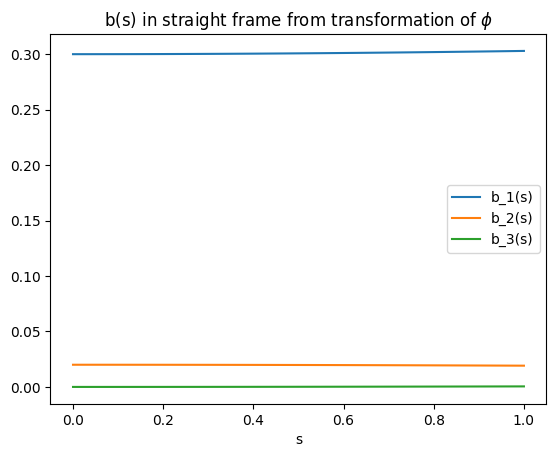

phi0= 0


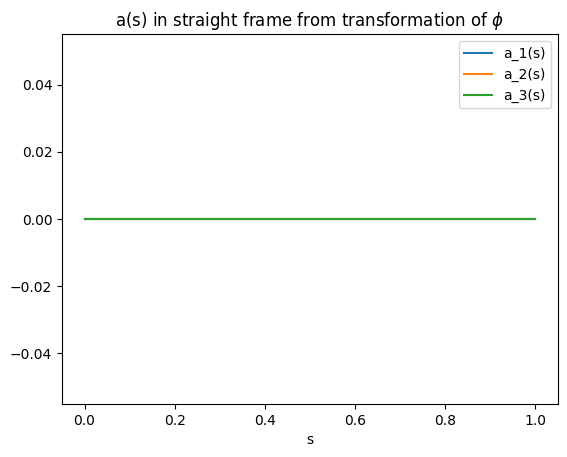

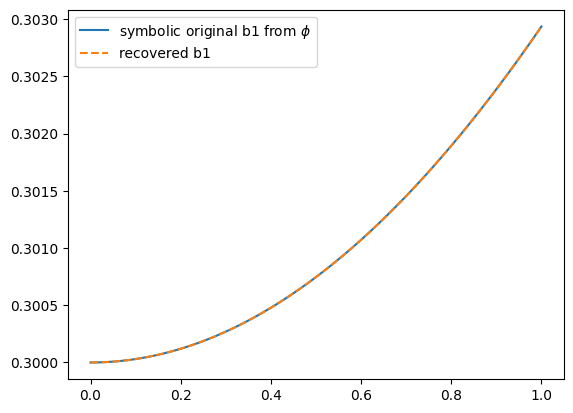

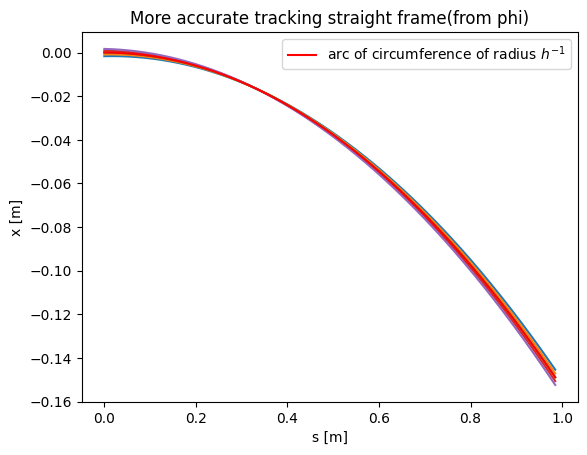

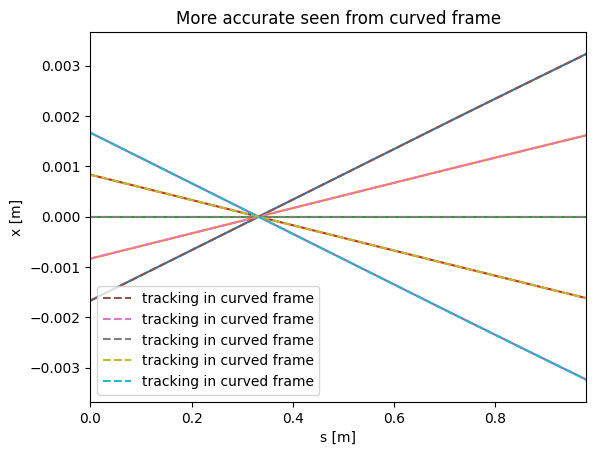

[order 2] particle 0: dx_exit = 1.007e-09 m, RMS_x = 2.981e-09 m
[order 2] particle 1: dx_exit = -5.233e-08 m, RMS_x = 1.571e-09 m
[order 2] particle 2: dx_exit = -1.401e-07 m, RMS_x = 8.377e-10 m
[order 2] particle 3: dx_exit = -4.503e-08 m, RMS_x = 7.009e-10 m
[order 2] particle 4: dx_exit = 2.994e-09 m, RMS_x = 7.042e-10 m
phi1= -0.003888*s**6*sqrt(s**2 + x**2 + 6.66666666666667*x + 11.1111111111111)/(0.1944*s**6 + 0.5832*s**4*x**2 + 3.888*s**4*x + 6.48*s**4 + 0.5832*s**2*x**4 + 7.776*s**2*x**3 + 38.88*s**2*x**2 + 86.4*s**2*x - 7.105427357601e-15*s**2*sqrt(s**2 + x**2 + 6.66666666666667*x + 11.1111111111111) + 72.0*s**2 + 0.1944*x**6 + 3.888*x**5 + 32.4*x**4 + 144.0*x**3 - 7.105427357601e-15*x**2*sqrt(s**2 + x**2 + 6.66666666666667*x + 11.1111111111111) + 360.0*x**2 - 4.736951571734e-14*x*sqrt(s**2 + x**2 + 6.66666666666667*x + 11.1111111111111) + 480.0*x - 7.89491928622334e-14*sqrt(s**2 + x**2 + 6.66666666666667*x + 11.1111111111111) + 266.666666666666) - 0.04536*s**6/(0.1944*s**6 

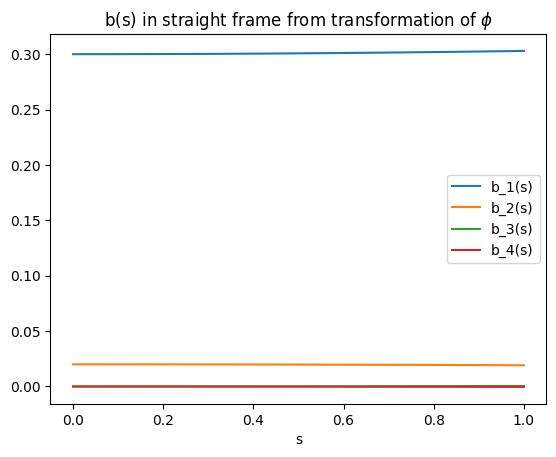

phi0= 0


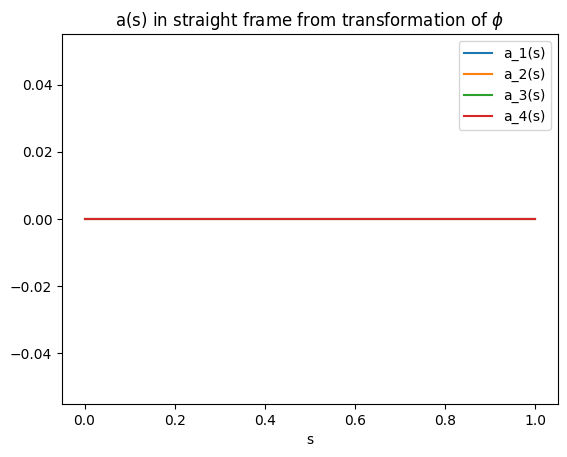

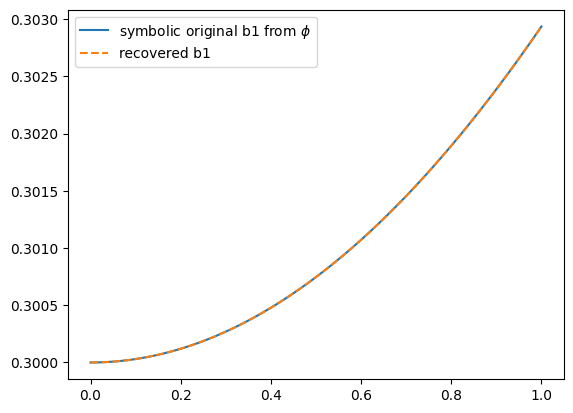

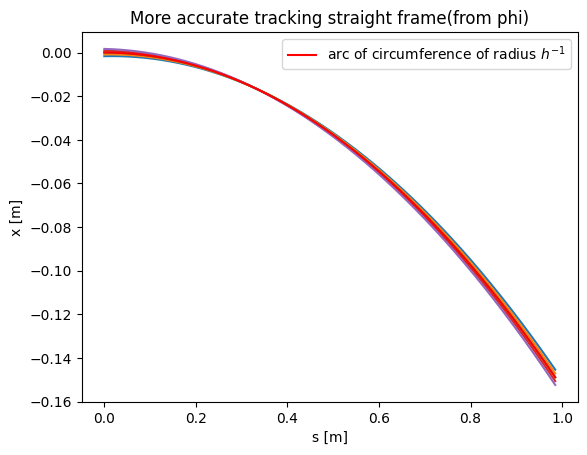

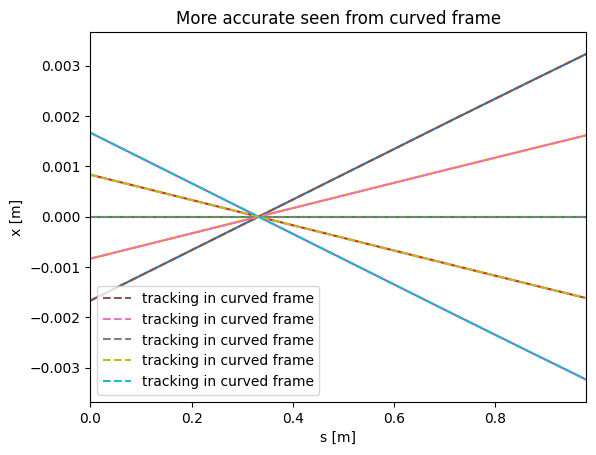

[order 3] particle 0: dx_exit = 1.769e-10 m, RMS_x = 2.930e-09 m
[order 3] particle 1: dx_exit = -5.320e-08 m, RMS_x = 1.463e-09 m
[order 3] particle 2: dx_exit = -1.410e-07 m, RMS_x = 5.832e-10 m
[order 3] particle 3: dx_exit = -4.597e-08 m, RMS_x = 3.680e-10 m
[order 3] particle 4: dx_exit = 2.021e-09 m, RMS_x = 3.035e-10 m
phi1= -0.003888*s**6*sqrt(s**2 + x**2 + 6.66666666666667*x + 11.1111111111111)/(0.1944*s**6 + 0.5832*s**4*x**2 + 3.888*s**4*x + 6.48*s**4 + 0.5832*s**2*x**4 + 7.776*s**2*x**3 + 38.88*s**2*x**2 + 86.4*s**2*x - 7.105427357601e-15*s**2*sqrt(s**2 + x**2 + 6.66666666666667*x + 11.1111111111111) + 72.0*s**2 + 0.1944*x**6 + 3.888*x**5 + 32.4*x**4 + 144.0*x**3 - 7.105427357601e-15*x**2*sqrt(s**2 + x**2 + 6.66666666666667*x + 11.1111111111111) + 360.0*x**2 - 4.736951571734e-14*x*sqrt(s**2 + x**2 + 6.66666666666667*x + 11.1111111111111) + 480.0*x - 7.89491928622334e-14*sqrt(s**2 + x**2 + 6.66666666666667*x + 11.1111111111111) + 266.666666666666) - 0.04536*s**6/(0.1944*s**6 

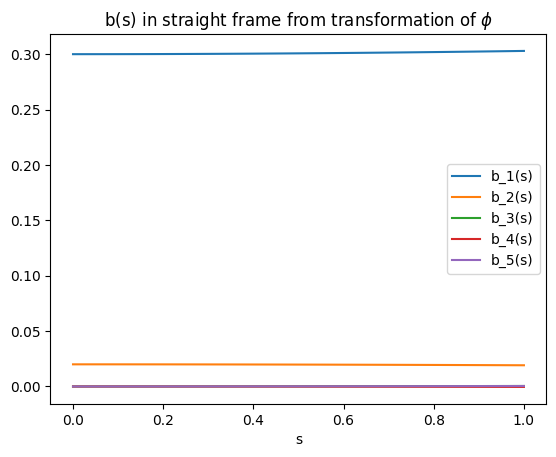

phi0= 0


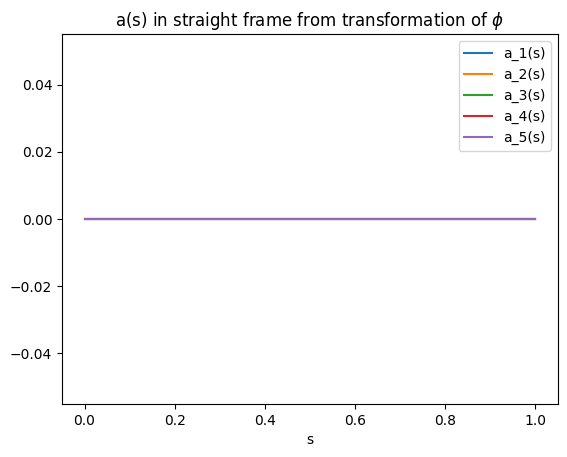

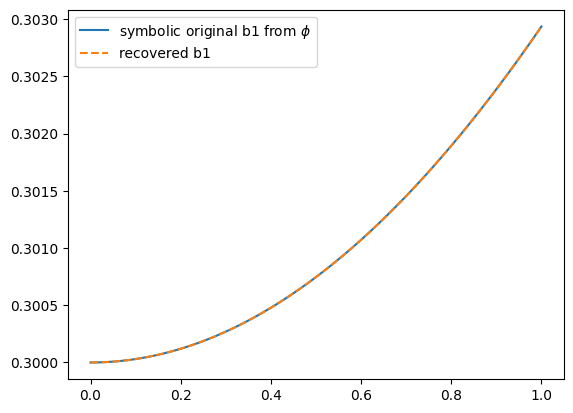

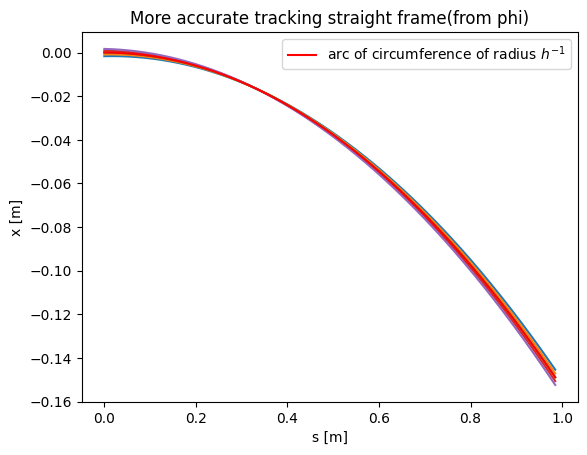

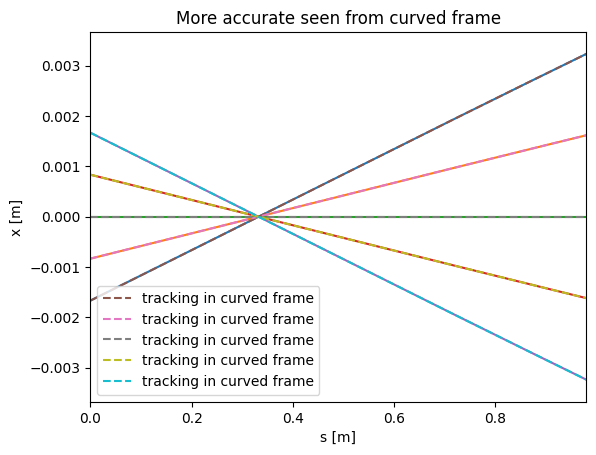

[order 4] particle 0: dx_exit = 1.586e-10 m, RMS_x = 2.930e-09 m
[order 4] particle 1: dx_exit = -5.322e-08 m, RMS_x = 1.463e-09 m
[order 4] particle 2: dx_exit = -1.410e-07 m, RMS_x = 5.829e-10 m
[order 4] particle 3: dx_exit = -4.599e-08 m, RMS_x = 3.684e-10 m
[order 4] particle 4: dx_exit = 1.998e-09 m, RMS_x = 3.031e-10 m
phi1= -0.003888*s**6*sqrt(s**2 + x**2 + 6.66666666666667*x + 11.1111111111111)/(0.1944*s**6 + 0.5832*s**4*x**2 + 3.888*s**4*x + 6.48*s**4 + 0.5832*s**2*x**4 + 7.776*s**2*x**3 + 38.88*s**2*x**2 + 86.4*s**2*x - 7.105427357601e-15*s**2*sqrt(s**2 + x**2 + 6.66666666666667*x + 11.1111111111111) + 72.0*s**2 + 0.1944*x**6 + 3.888*x**5 + 32.4*x**4 + 144.0*x**3 - 7.105427357601e-15*x**2*sqrt(s**2 + x**2 + 6.66666666666667*x + 11.1111111111111) + 360.0*x**2 - 4.736951571734e-14*x*sqrt(s**2 + x**2 + 6.66666666666667*x + 11.1111111111111) + 480.0*x - 7.89491928622334e-14*sqrt(s**2 + x**2 + 6.66666666666667*x + 11.1111111111111) + 266.666666666666) - 0.04536*s**6/(0.1944*s**6 

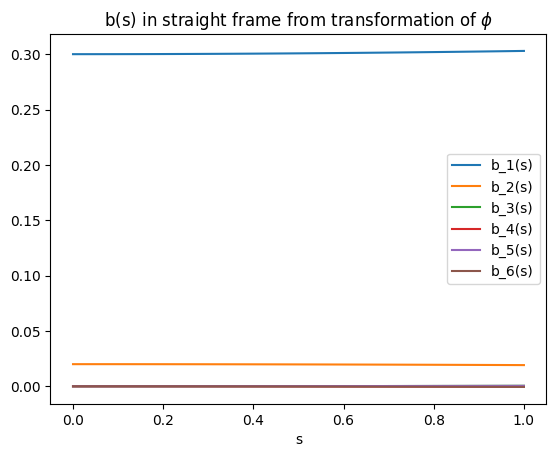

phi0= 0


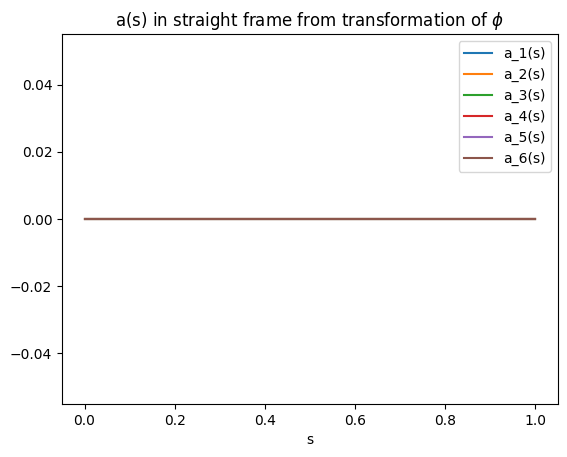

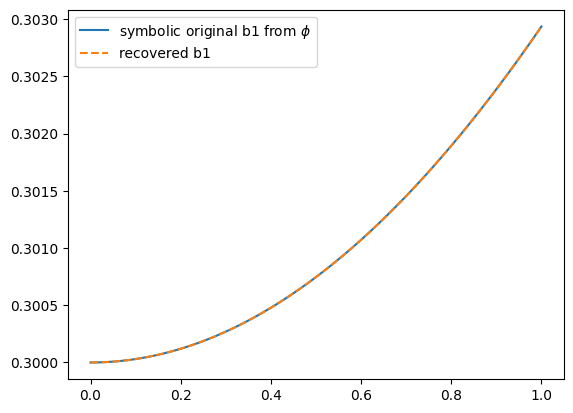

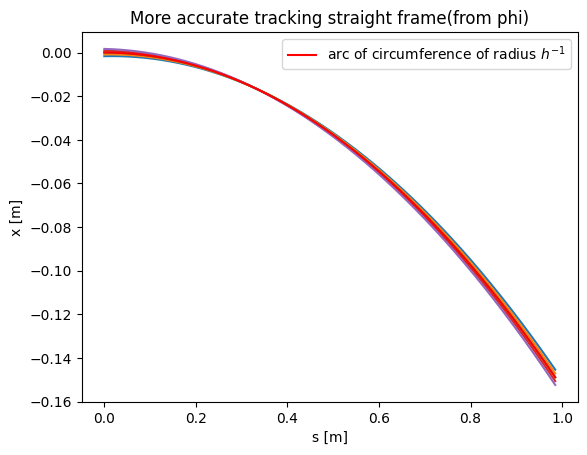

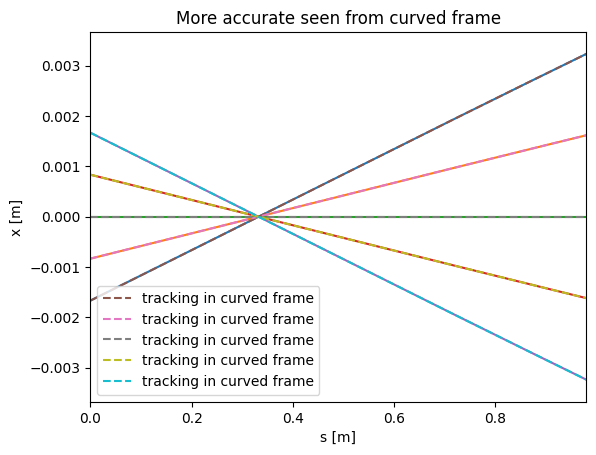

[order 5] particle 0: dx_exit = 1.582e-10 m, RMS_x = 2.930e-09 m
[order 5] particle 1: dx_exit = -5.322e-08 m, RMS_x = 1.463e-09 m
[order 5] particle 2: dx_exit = -1.410e-07 m, RMS_x = 5.829e-10 m
[order 5] particle 3: dx_exit = -4.599e-08 m, RMS_x = 3.684e-10 m
[order 5] particle 4: dx_exit = 1.997e-09 m, RMS_x = 3.030e-10 m
phi1= -0.003888*s**6*sqrt(s**2 + x**2 + 6.66666666666667*x + 11.1111111111111)/(0.1944*s**6 + 0.5832*s**4*x**2 + 3.888*s**4*x + 6.48*s**4 + 0.5832*s**2*x**4 + 7.776*s**2*x**3 + 38.88*s**2*x**2 + 86.4*s**2*x - 7.105427357601e-15*s**2*sqrt(s**2 + x**2 + 6.66666666666667*x + 11.1111111111111) + 72.0*s**2 + 0.1944*x**6 + 3.888*x**5 + 32.4*x**4 + 144.0*x**3 - 7.105427357601e-15*x**2*sqrt(s**2 + x**2 + 6.66666666666667*x + 11.1111111111111) + 360.0*x**2 - 4.736951571734e-14*x*sqrt(s**2 + x**2 + 6.66666666666667*x + 11.1111111111111) + 480.0*x - 7.89491928622334e-14*sqrt(s**2 + x**2 + 6.66666666666667*x + 11.1111111111111) + 266.666666666666) - 0.04536*s**6/(0.1944*s**6 

In [23]:
import pandas as pd

orders = [2, 3, 4, 5, 6, 7]
results = []

for ordx in orders:
    maxordx = ordx

    # --------------------------------------------------
    # put here the code that depends on maxordx and that
    # regenerates sol_strfromphi and sol_curved
    # --------------------------------------------------
    x, y, s = sp.symbols('x y s', real=True)
    ns=101
    phi_straight_exp = sp.expand(phi_straight)
    phi1 = phi_straight_exp.as_coefficients_dict(y)[y]
    print("phi1=",phi1) 
    ss = np.linspace(0, 1, ns)
    if phi1==0:
        # safety check for when all b_n(s) are zero, one can just create zero arrays with the right shape
    
        b_vals = np.zeros((maxordx+1, ss.size))
    else:
        phi1_series = phi1.series(x, 0, maxordx+1).removeO()
        dct_b = phi1_series.as_coefficients_dict(x)
        # ... then extract a_n(s) as in the previous case
        items_b = sorted(dct_b.items(), key=lambda kv: sp.degree(kv[0], x))

    b_vals = np.zeros((maxordx+1, ss.size))   # include b_0
    if phi1 != 0:
        # 2. Nontrivial phi0: do series in x and extract b_n(s)
        phi1_series = phi1.series(x, 0, maxordx+1).removeO()
        dct_b = phi1_series.as_coefficients_dict(x)

        items_b = sorted(dct_b.items(), key=lambda kv: sp.degree(kv[0], x))

        for k, (xx, vv) in enumerate(items_b):
            if k == 0:
                b_k = -vv                    # b_1(s)
                label = "b_1(s)"
            else:
                b_k = -vv * sp.factorial(k)  # b_k(s)
                label = f"b_{k+1}(s)"

            b_fun = sp.lambdify(s, b_k, 'numpy')
            b_vals[k, :] = b_fun(ss)

            plt.plot(ss, b_vals[k, :], label=label)
    else:
        # 3. phi1 == 0: everything is zero; optionally still plot flat lines
        for k in range(maxordx+1):
            label = f"b_{k+1}(s)"
            # a_vals is already zero
            plt.plot(ss, b_vals[k, :], label=label)

    plt.legend()
    plt.title("b(s) in straight frame from transformation of $\phi$")
    plt.xlabel("s")
    plt.show()
    ############################################
    phi0 = phi_straight.as_coefficients_dict(y)[1]   # phi_0(x, s)
    print("phi0=",phi0)        # you'll see 0 in this case

    if phi0 == 0:
        # safety check for when all a_n(s) are zero, one can just create zero arrays with the right shape
        #ss = np.linspace(0, 1, ns)
        a_vals = np.zeros((maxordx+1, ss.size))
    else:
        phi0_series = phi0.series(x, 0, maxordx+1).removeO()
        dct_a = phi0_series.as_coefficients_dict(x)
        # ... then extract a_n(s) as in the previous case
        items_a = sorted(dct_a.items(), key=lambda kv: sp.degree(kv[0], x))

    a_vals = np.zeros((maxordx+1, ss.size))   # include a_0
    if phi0 != 0:
        # 2. Nontrivial phi0: do series in x and extract a_n(s)
        phi0_series = phi0.series(x, 0, maxordx+1).removeO()
        dct_a = phi0_series.as_coefficients_dict(x)

        items_a = sorted(dct_a.items(), key=lambda kv: sp.degree(kv[0], x))

        for k, (xx, vv) in enumerate(items_a):
            if k == 0:
                a_k = -vv                    # a_0(s)
                label = "a_1(s)"
            else:
                a_k = -vv * sp.factorial(k)  # a_k(s)
                label = f"a_{k+1}(s)"

            a_fun = sp.lambdify(s, a_k, 'numpy')
            a_vals[k, :] = a_fun(ss)

            plt.plot(ss, a_vals[k, :], label=label)
    else:
        # 3. phi0 == 0: everything is zero; optionally still plot flat lines
        for k in range(maxordx+1):
            label = f"a_{k+1}(s)"
            # a_vals is already zero
            plt.plot(ss, a_vals[k, :], label=label)

    plt.legend()
    plt.title("a(s) in straight frame from transformation of $\phi$")
    plt.xlabel("s")
    plt.show()

    b_fromphifit = []# I need symbolic expressions of the coefficients as input
    a_fromphifit = []
    s = sp.symbols('s')
    sstraightarray = ss
    degree = 10

    for arr, dst in [(b_vals.T, b_fromphifit), (a_vals.T, a_fromphifit)]:
        for j in range(arr.shape[1]):
            cheb = np.polynomial.Chebyshev.fit(sstraightarray, arr[:, j], deg=degree, domain=[0, 1])
            poly = cheb.convert(kind=np.polynomial.Polynomial)
            coeffs = poly.coef
            poly_expr = sum(sp.Float(coeffs[i]) * s**i for i in range(len(coeffs)))
            dst.append(sp.expand(poly_expr))   # store SymPy expr, not str


    plt.plot(sstraightarray, b_vals.T[:, 0], label=r"symbolic original b1 from $\phi$")
    # use b_fromphifit (not b_nfit), index 0 = b_1(s)
    b1ofsfromphilambdified = sp.lambdify(s, b_fromphifit[0], modules='numpy')
    plt.plot(sstraightarray, b1ofsfromphilambdified(sstraightarray)*np.ones_like(sstraightarray), '--', label='recovered b1')
    plt.legend()
    plt.show()
    
    Astrfromphi=bpmeth.GeneralVectorPotential(h=0, b=b_fromphifit, a=a_fromphifit, nphi=maxordx+4)#s dependence of the coefficients
    Lstr=np.sin(bending_angle)/h
    Hstrfromphi = bpmeth.Hamiltonian(length=Lstr,h=0, vectp=Astrfromphi)
    p_4 = p0.copy()
    sol_strfromphi = Hstrfromphi.track(p_4, return_sol=True, ivp_opt= {"rtol":1e-10, "atol":1e-12})
    for ss in sol_strfromphi:
        plt.plot(ss.t, ss.y[0])
    plt.xlabel('s [m]')
    plt.ylabel('x [m]')
    plt.title("More accurate tracking straight frame(from phi)")
    x=np.linspace(0,Lstr,50)
    y= -1/h +np.sqrt(h**-2 -x**2)
    plt.plot(x,y, color='red', label='arc of circumference of radius $h^{-1}$')
    #plt.xlim((0., .98))#because H curved has length 1
    plt.legend()
    plt.show()
    #visualise from the pov of the curved frame
    for ss in sol_strfromphi:
        xc=np.sqrt((ss.y[0]+1/h)**2+ss.t**2)-1/h
        sc=np.arctan(ss.t/(ss.y[0]+1/h))/h
        plt.plot(sc,xc)
    plt.xlabel('s [m]')
    plt.ylabel('x [m]')
    plt.title("More accurate seen from curved frame")
    # x=np.linspace(0,1,50)
    # y= np.zeros(50)
    # plt.plot(x,y, color='red', label='arc of circumference of radius h^-1')
    for ss in sol_curved:
        plt.plot(ss.t, ss.y[0],'--',label='tracking in curved frame')
    plt.legend()
    plt.xlim((0., .98))#because H curved has length 1
    plt.show()
    sbar_fin = Lstr - 0.1
    rho = 1.0 / h
    out = compute_rms_for_order(
        maxordx=maxordx,
        sol_strfromphi=sol_strfromphi,
        sol_curved=sol_curved,
        Lstr=Lstr,
        make_particle_plots=False
    )
    results.append(out)

df_conv = pd.DataFrame(
    {
        "maxordx": [r["maxordx"] for r in results],
        "mean_dx_exit": [r["mean_dx_exit"] for r in results],
        "mean_rms_x": [r["mean_rms_x"] for r in results],
    }
)

display(df_conv)

In [ ]:
def precompute_phi_coeffs(phi_straight, max_order_global, ss, cheb_degree=10):
    x, y, s = sp.symbols('x y s', real=True)

    phi_straight_exp = sp.expand(phi_straight)
    phi1 = phi_straight_exp.as_coefficients_dict(y)[y]
    phi0 = phi_straight_exp.as_coefficients_dict(y)[1]

    def extract_coeff_list(phi_piece, max_order):
        vals = np.zeros((max_order + 1, ss.size))
        exprs = [sp.Integer(0)] * (max_order + 1)

        if phi_piece == 0:
            return vals, exprs

        series = phi_piece.series(x, 0, max_order + 1).removeO()
        dct = series.as_coefficients_dict(x)

        for n in range(max_order + 1):
            coeff = dct.get(x**n, 0)
            if n == 0:
                expr_n = -coeff
            else:
                expr_n = -coeff * sp.factorial(n)

            exprs[n] = sp.expand(expr_n)
            vals[n, :] = sp.lambdify(s, exprs[n], "numpy")(ss)

        return vals, exprs

    b_vals_all, b_exprs_all = extract_coeff_list(phi1, max_order_global)
    a_vals_all, a_exprs_all = extract_coeff_list(phi0, max_order_global)

    def cheb_fit_exprs(vals):
        out = []
        for j in range(vals.shape[0]):
            cheb = np.polynomial.Chebyshev.fit(ss, vals[j, :], deg=cheb_degree, domain=[0, 1])
            poly = cheb.convert(kind=np.polynomial.Polynomial)
            coeffs = poly.coef
            expr = sum(sp.Float(coeffs[k]) * s**k for k in range(len(coeffs)))
            out.append(sp.expand(expr))
        return out

    b_fit_all = cheb_fit_exprs(b_vals_all)
    a_fit_all = cheb_fit_exprs(a_vals_all)

    return {
        "ss": ss,
        "a_vals_all": a_vals_all,
        "b_vals_all": b_vals_all,
        "a_fit_all": a_fit_all,
        "b_fit_all": b_fit_all,
    }

orders = [2, 3, 4, 5, 6, 7]
max_order_global = max(orders)
ns = 101
ss = np.linspace(0, 1, ns)

pre = precompute_phi_coeffs(phi_straight, max_order_global, ss, cheb_degree=10)

results = []

for ordx in orders:
    b_fromphifit = pre["b_fit_all"][:ordx+1]
    a_fromphifit = pre["a_fit_all"][:ordx+1]

    Astrfromphi = bpmeth.GeneralVectorPotential(
        h=0,
        b=b_fromphifit,
        a=a_fromphifit,
        nphi=ordx + 4
    )

    Lstr = np.sin(bending_angle) / h
    Hstrfromphi = bpmeth.Hamiltonian(length=Lstr, h=0, vectp=Astrfromphi)

    p_4 = p0.copy()
    sol_strfromphi = Hstrfromphi.track(
        p_4,
        return_sol=True,
        ivp_opt={"rtol": 1e-10, "atol": 1e-12}
    )

    out = compute_rms_for_order(
        maxordx=ordx,
        sol_strfromphi=sol_strfromphi,
        sol_curved=sol_curved,
        Lstr=Lstr,
        make_particle_plots=False
    )
    results.append(out)

Convergence for h=0.3/m

In [20]:
mean_rms_x_h03=df_conv["mean_rms_x"].values
print("mean_rms_x_h03=",mean_rms_x_h03)

mean_rms_x_h03= [1.36866369e-09 1.13469600e-09 1.13447743e-09 1.13447654e-09
 1.13447650e-09 1.13447650e-09]


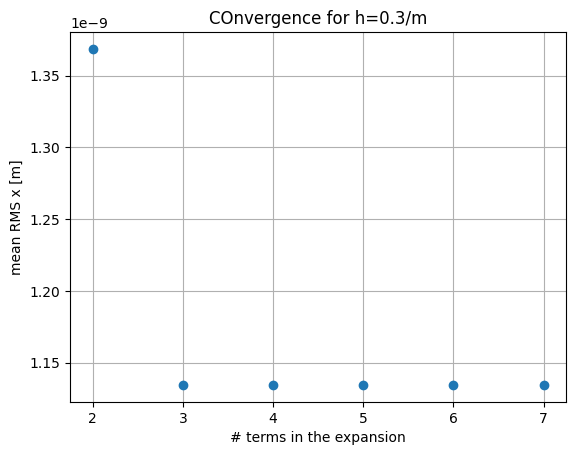

In [ ]:
plt.plot(df_conv["maxordx"], mean_rms_x_h03, "o", label=r"$\Delta x_{\mathrm{exit}}$")
plt.title('COnvergence for h='+str(h)+'/m')
plt.xlabel('# terms in the expansion')
plt.grid(True)
plt.ylabel('mean RMS x [m]')
plt.show()

## Change the quantity of terms in the recovered expression and see how convergence is affected

In [ ]:
maxordx=4
x, y, s = sp.symbols('x y s', real=True)
ns=101
phi_straight_exp = sp.expand(phi_straight)
phi1 = phi_straight_exp.as_coefficients_dict(y)[y]
print("phi1=",phi1) 
ss = np.linspace(0, 1, ns)
if phi1==0:
    # safety check for when all b_n(s) are zero, one can just create zero arrays with the right shape
  
    b_vals = np.zeros((maxordx+1, ss.size))
else:
    phi1_series = phi1.series(x, 0, maxordx+1).removeO()
    dct_b = phi1_series.as_coefficients_dict(x)
    # ... then extract a_n(s) as in the previous case
    items_b = sorted(dct_b.items(), key=lambda kv: sp.degree(kv[0], x))

b_vals = np.zeros((maxordx+1, ss.size))   # include b_0
if phi1 != 0:
    # 2. Nontrivial phi0: do series in x and extract b_n(s)
    phi1_series = phi1.series(x, 0, maxordx+1).removeO()
    dct_b = phi1_series.as_coefficients_dict(x)

    items_b = sorted(dct_b.items(), key=lambda kv: sp.degree(kv[0], x))

    for k, (xx, vv) in enumerate(items_b):
        if k == 0:
            b_k = -vv                    # b_1(s)
            label = "b_1(s)"
        else:
            b_k = -vv * sp.factorial(k)  # b_k(s)
            label = f"b_{k+1}(s)"

        b_fun = sp.lambdify(s, b_k, 'numpy')
        b_vals[k, :] = b_fun(ss)

        plt.plot(ss, b_vals[k, :], label=label)
else:
    # 3. phi1 == 0: everything is zero; optionally still plot flat lines
    for k in range(maxordx+1):
        label = f"b_{k+1}(s)"
        # a_vals is already zero
        plt.plot(ss, b_vals[k, :], label=label)

plt.legend()
plt.title("b(s) in straight frame from transformation of $\phi$")
plt.xlabel("s")
plt.show()
############################################
phi0 = phi_straight.as_coefficients_dict(y)[1]   # phi_0(x, s)
print("phi0=",phi0)        # you'll see 0 in this case

if phi0 == 0:
    # safety check for when all a_n(s) are zero, one can just create zero arrays with the right shape
    #ss = np.linspace(0, 1, ns)
    a_vals = np.zeros((maxordx+1, ss.size))
else:
    phi0_series = phi0.series(x, 0, maxordx+1).removeO()
    dct_a = phi0_series.as_coefficients_dict(x)
    # ... then extract a_n(s) as in the previous case
    items_a = sorted(dct_a.items(), key=lambda kv: sp.degree(kv[0], x))

a_vals = np.zeros((maxordx+1, ss.size))   # include a_0
if phi0 != 0:
    # 2. Nontrivial phi0: do series in x and extract a_n(s)
    phi0_series = phi0.series(x, 0, maxordx+1).removeO()
    dct_a = phi0_series.as_coefficients_dict(x)

    items_a = sorted(dct_a.items(), key=lambda kv: sp.degree(kv[0], x))

    for k, (xx, vv) in enumerate(items_a):
        if k == 0:
            a_k = -vv                    # a_0(s)
            label = "a_1(s)"
        else:
            a_k = -vv * sp.factorial(k)  # a_k(s)
            label = f"a_{k+1}(s)"

        a_fun = sp.lambdify(s, a_k, 'numpy')
        a_vals[k, :] = a_fun(ss)

        plt.plot(ss, a_vals[k, :], label=label)
else:
    # 3. phi0 == 0: everything is zero; optionally still plot flat lines
    for k in range(maxordx+1):
        label = f"a_{k+1}(s)"
        # a_vals is already zero
        plt.plot(ss, a_vals[k, :], label=label)

plt.legend()
plt.title("a(s) in straight frame from transformation of $\phi$")
plt.xlabel("s")
plt.show()

In [ ]:
b_fromphifit = []# I need symbolic expressions of the coefficients as input
a_fromphifit = []
s = sp.symbols('s')
sstraightarray = ss
degree = 10

for arr, dst in [(b_vals.T, b_fromphifit), (a_vals.T, a_fromphifit)]:
    for j in range(arr.shape[1]):
        cheb = np.polynomial.Chebyshev.fit(sstraightarray, arr[:, j], deg=degree, domain=[0, 1])
        poly = cheb.convert(kind=np.polynomial.Polynomial)
        coeffs = poly.coef
        poly_expr = sum(sp.Float(coeffs[i]) * s**i for i in range(len(coeffs)))
        dst.append(sp.expand(poly_expr))   # store SymPy expr, not str


plt.plot(sstraightarray, b_vals.T[:, 0], label=r"symbolic original b1 from $\phi$")
# use b_fromphifit (not b_nfit), index 0 = b_1(s)
b1ofsfromphilambdified = sp.lambdify(s, b_fromphifit[0], modules='numpy')
plt.plot(sstraightarray, b1ofsfromphilambdified(sstraightarray)*np.ones_like(sstraightarray), '--', label='recovered b1')
plt.legend()
plt.show()

In [ ]:
Astrfromphi=bpmeth.GeneralVectorPotential(h=0, b=b_fromphifit, a=a_fromphifit, nphi=maxordx+4)#s dependence of the coefficients
Lstr=np.sin(bending_angle)/h
Hstrfromphi = bpmeth.Hamiltonian(length=Lstr,h=0, vectp=Astrfromphi)
p_4 = p0.copy()
sol_strfromphi = Hstrfromphi.track(p_4, return_sol=True, ivp_opt= {"rtol":1e-10, "atol":1e-12})
for ss in sol_strfromphi:
    plt.plot(ss.t, ss.y[0])
plt.xlabel('s [m]')
plt.ylabel('x [m]')
plt.title("More accurate tracking straight frame(from phi)")
x=np.linspace(0,Lstr,50)
y= -1/h +np.sqrt(h**-2 -x**2)
plt.plot(x,y, color='red', label='arc of circumference of radius $h^{-1}$')
#plt.xlim((0., .98))#because H curved has length 1
plt.legend()
plt.show()
#visualise from the pov of the curved frame
for ss in sol_strfromphi:
    xc=np.sqrt((ss.y[0]+1/h)**2+ss.t**2)-1/h
    sc=np.arctan(ss.t/(ss.y[0]+1/h))/h
    plt.plot(sc,xc)
plt.xlabel('s [m]')
plt.ylabel('x [m]')
plt.title("More accurate seen from curved frame")
# x=np.linspace(0,1,50)
# y= np.zeros(50)
# plt.plot(x,y, color='red', label='arc of circumference of radius h^-1')
for ss in sol_curved:
    plt.plot(ss.t, ss.y[0],'--',label='tracking in curved frame')
plt.legend()
plt.xlim((0., .98))#because H curved has length 1
plt.show()

In [ ]:
sbar_fin = Lstr-0.1         # chosen exit position in straight frame [m]
rho = 1.0 / h
from scipy.interpolate import PchipInterpolator
dx_exit_list = []      # Δx at exit
rms_x_list = []        # RMS over magnet

for i, (sb, sa) in enumerate(zip(sol_strfromphi, sol_curved)):
    # --- straight-frame tracking ---
    sbar_str = sb.t        # straight longitudinal coordinate \bar{s}
    xbar_str = sb.y[0]     # straight transverse coordinate \bar{x}

    # --- curved-frame tracking, transformed into straight frame ---
    s_curv = sa.t
    x_curv = sa.y[0]

    sbar_from_curv = (rho + x_curv) * np.sin(s_curv / rho)
    xbar_from_curv = -rho + (rho + x_curv) * np.cos(s_curv / rho)

    # --- common sbar range for RMS ---
    sbar_min = max(sbar_str.min(), sbar_from_curv.min())
    sbar_max = min(sbar_str.max(), sbar_from_curv.max())
    if sbar_max <= sbar_min:
        print(f"particle {i}: no overlap in sbar range, skipping")
        continue

    sbar_common = np.linspace(sbar_min, sbar_max, 500)
    print('s_bar_min of particle'+str(i)+'='+str(sbar_min))
    print('s_bar_max of particle'+str(i)+'='+str(sbar_max))

    # interpolate straight tracking onto sbar_common
    xbar_str_common = PchipInterpolator(sbar_str, xbar_str)(sbar_common)

    # interpolate curved→straight tracking onto sbar_common
    idx_curv = np.argsort(sbar_from_curv)
    sbar_sorted = sbar_from_curv[idx_curv]
    xbar_sorted = xbar_from_curv[idx_curv]

    xbar_curv_common = PchipInterpolator(sbar_sorted, xbar_sorted)(sbar_common)

    # --- RMS difference over magnet ---
    dx_all = xbar_str_common - xbar_curv_common
    rms_x = np.sqrt(np.mean(dx_all**2))
    rms_x_list.append(rms_x)

    # --- difference at exit sbar_fin (local diagnostic) ---
    # straight x at exit
    xbar_exit_straight = np.interp(sbar_fin, sbar_str, xbar_str)

    # curved→straight x at the same exit
    # reuse sorted arrays; interpolate in sbar0.10062689441112445
    xbar_exit_from_curv = np.interp(sbar_fin, sbar_sorted, xbar_sorted)

    dx_exit = xbar_exit_straight - xbar_exit_from_curv
    dx_exit_list.append(dx_exit)

    print(
        f"particle {i}: "
        f"dx_exit = {dx_exit:.3e} m, "
        f"RMS_x = {rms_x:.3e} m"
    )

# optional: summary plots
plt.figure()
plt.plot(range(len(dx_exit_list)), dx_exit_list, "o")
plt.xlabel("particle index")
plt.ylabel(r"$\Delta x_{\text{exit}}$ [m]")
plt.title('Difference between x positions at the exit of the magnet predicted by the two trackings using $\phi$ transformation of order '+str(maxordx))
plt.grid(True)

plt.figure()
plt.plot(range(len(rms_x_list)), rms_x_list, "o")
plt.xlabel("particle index")
plt.ylabel(r"RMS$_x$ over magnet [m]")
plt.title('RMS difference in x along the magnet predicted by the two trackings using $\phi$ transformation of order '+str(maxordx))
plt.grid(True)
plt.show()

print("average final delta x between particles using phi transf. of order "+str(maxordx)+"="+str( np.mean(dx_exit_list)))
print("average RMS x between particles using phi transf. of order "+str(maxordx)+"="+str( np.mean(rms_x_list)))

## The following results were obtained without fixing bending angle and max(hx)

Convergence for h=0.3/m

In [ ]:
orders=np.linspace(2,7,6)
rmsxoforder_h0_3=[6.120518339058754e-10,
                 1.0935479263137754e-10,
                 1.0741192674724452e-10,
                 1.0738539052939527e-10,
                 1.0738459985197033e-10,
                 1.0738457600405461e-10]
plt.plot(orders[:], rmsxoforder_h0_3[:], "o")
plt.ylabel(r"RMS$_x$ over magnet [m]")
plt.xlabel('maximum order')
plt.yscale('log')
plt.title('Convergence for h=0.3/m')
plt.grid(True)
plt.show()

Convergence for h=10/m

In [ ]:
orders=np.linspace(2,7,6)
rmsxoforder_h10=[0.10062689755970562,
                 0.10062689504815614,
                 0.10062689451058793,
                 0.10062689441112445,
                 0.10062689439921688,
                 0.10062689440105466]
plt.plot(orders[:], rmsxoforder_h10[:], "o")
plt.ylabel(r"RMS$_x$ over magnet [m]")
plt.xlabel('maximum order')
plt.yscale('log')
plt.title('Convergence for h=10/m')
plt.grid(True)
plt.show()

Convergence for h=0.8/m

In [ ]:
orders=np.linspace(2,7,6)
rmsxoforder_h0_8=[3.5097878738111827e-07,
                  4.260057789088021e-08,
                  4.7221283470399305e-09,
                  6.014730201977918e-10,
                  4.438872264399038e-10,
                  4.4385620706491284e-10]
plt.plot(orders[:], rmsxoforder_h0_8[:], "o")
plt.ylabel(r"RMS$_x$ over magnet [m]")
plt.xlabel('maximum order')
plt.yscale('log')
plt.title('Convergence for h=0.8/m')
plt.grid(True)
plt.show()

Convergence for h=2/m

In [ ]:
orders=np.linspace(2,7,6)
rmsxoforder_h2=[0.054030865459648095,
                0.05402833628680542,
                0.054027757675104815,
                0.05402767136544838,
                0.05402768121906186,
                0.054027695584995504]
plt.plot(orders[:], rmsxoforder_h2[:], "o")
plt.ylabel(r"RMS$_x$ over magnet [m]")
plt.xlabel('maximum order')
plt.yscale('log')
plt.title('Convergence for h=2/m')
plt.grid(True)
plt.show()


Convergence rate for h=0.1/m

In [ ]:
orders=np.linspace(2,7,6)
rmsxoforder_h0_1=[2.3904610620580346e-11,
2.376138832911979e-11,
2.376100461722642e-11,
2.3761005058663768e-11,
2.376100453994024e-11,
2.3761004666687316e-11]



plt.plot(orders[:], rmsxoforder_h0_1[:], "o")
plt.ylabel(r"RMS$_x$ over magnet [m]")
plt.xlabel('maximum order')
plt.yscale('log')
plt.title('Convergence for h=0.1/m')
plt.grid(True)
plt.show()
